In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import matplotlib.patheffects as pe

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_AR_from_Q, collect_tracking_R, tracking_kdtree, day_plot


In [4]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


Cleaning.
1. Valid data for both inner- and outer-core data i.e. .dropna()
2. Cyclonicity must match
3. Reasonable values i.e. (Rc <= 300, |w| <= 1e-3), detQ = 1, DOPPIO center must be reasonably close to nencioli center

In [5]:
df_doppio = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_DOPPIO_SEACOFS_26yr.pkl')
df_doppio['w'] *= 1e-3; df_doppio['Omega0'] *= 1e-3; df_doppio['Omega'] *= 1e-3; #df_doppio['psi0'] *= 1e9
df_doppio


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416246,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,0.000012,110.552001,-72.997132,43.099927
416247,10650,10641,973.0,126.0,CE,978.294053,127.970950,-0.000004,"[[0.6233322936879349, -0.5502050858849237], [-...",-0.000001,-0.000002,75.127332,4.241051,34.482872
416248,10650,10641,805.0,95.0,AE,804.765913,95.382012,0.000011,"[[1.2619918374118362, 0.3980497594289241], [0....",0.000005,0.000006,60.426625,-10.779905,45.893895
416249,10650,10641,157.0,34.0,CE,157.210669,33.449590,-0.000007,"[[0.9874338034387458, 0.628992620695803], [0.6...",-0.000003,-0.000004,141.142981,36.082072,34.764443


In [6]:
# --- 1. Drop NaNs ---
df_clean1 = df_doppio.dropna().copy()
print(f'1. Removed {len(df_doppio) - len(df_clean1)} eddy-days')

# --- 2. Cyclonicity match ---
nenc_cyc = np.where(df_clean1['nCyc'].values == 'AE', 1, -1)
doppio_cyc = np.sign(df_clean1['w'].values)
cyc_mask = nenc_cyc == doppio_cyc
df_clean2 = df_clean1.loc[cyc_mask].copy()
print(f'2. Removed {len(df_clean1) - len(df_clean2)} eddy-days')

# --- 3. Derived diagnostics ---
df_clean2['AR'] = compute_AR_from_Q(np.stack(df_clean2['Q'].values))

detQ = df_clean2['Q'].apply(lambda Q: Q[0,0]*Q[1,1] - Q[1,0]**2).values

err = np.hypot(
    df_clean2['xc'].values - df_clean2['nxc'].values,
    df_clean2['yc'].values - df_clean2['nyc'].values
)

# --- 4. Hard validity masks ---
boundary_mask = (
    (df_clean2['xc'].values > 0)
    & (df_clean2['xc'].values < X_grid.max())
    & (df_clean2['yc'].values > 0)
    & (df_clean2['yc'].values < Y_grid.max())
)

det_mask = np.isclose(detQ, 1, atol=1e-5)

# --- robust center error (converted to physical bounds) ---
log_err = np.log1p(err)
err_med = np.median(log_err)
err_mad = np.median(np.abs(log_err - err_med))
err_mad = np.nan if err_mad == 0 else err_mad

threshold = 4

lower_log = err_med - (threshold * err_mad / 0.6745)
upper_log = err_med + (threshold * err_mad / 0.6745)

lower_err = 0
upper_err = np.expm1(upper_log)

center_mask = (err >= lower_err) & (err <= upper_err)

# --- simple sanity ---
sanity_mask = (
    (df_clean2['Rc'].values > 0)
    & (df_clean2['AR'].values >= 1)
)

# --- 5. Robust outlier removal ---
df_out = df_clean2.copy()
df_out['w_abs'] = df_out['w'].abs()
df_out['Omega_abs'] = df_out['Omega'].abs()
df_out['psi0_abs'] = df_out['psi0'].abs()

cols = ['w_abs', 'Omega_abs', 'Rc', 'psi0_abs', 'AR']

median = df_out[cols].median()
mad = (df_out[cols] - median).abs().median()
mad = mad.replace(0, np.nan)

# --- compute bounds ---
lower = median - (threshold * mad / 0.6745)
upper = median + (threshold * mad / 0.6745)

# --- enforce physical lower bounds ---
lower_bounds = {
    'w_abs': 0,
    'Omega_abs': 0,
    'Rc': 0,
    'psi0_abs': 0,
    'AR': 1,
}

for col, lb in lower_bounds.items():
    lower[col] = max(lower[col], lb)

# --- outlier mask ---
outlier_mask = ((df_out[cols] >= lower) & (df_out[cols] <= upper)).all(axis=1).values

# --- print thresholds ---
print("\nParameter thresholds (lower → upper):")
for col in cols:
    print(f"{col}: {lower[col]:.3e} → {upper[col]:.3e}")

print("\nCenter error threshold:")
print(f"err: {lower_err:.3f} km → {upper_err:.3f} km")

# --- 6. Combine masks ---
final_mask = (
    boundary_mask
    & det_mask
    & center_mask
    & sanity_mask
    & outlier_mask
)

df_clean = df_clean2.loc[final_mask].copy().reset_index(drop=True)

print(f'3. Removed {len(df_clean2) - len(df_clean)} eddy-days')
print(f'Final retained: {len(df_clean)} eddy-days')

1. Removed 39239 eddy-days
2. Removed 632 eddy-days

Parameter thresholds (lower → upper):
w_abs: 0.000e+00 → 5.871e-05
Omega_abs: 0.000e+00 → 2.673e-05
Rc: 0.000e+00 → 2.472e+02
psi0_abs: 0.000e+00 → 9.178e+01
AR: 1.000e+00 → 4.054e+00

Center error threshold:
err: 0.000 km → 23.217 km
3. Removed 73217 eddy-days
Final retained: 303163 eddy-days


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR,err
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028,1.497688,0.321474
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171,1.491752,0.227335
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458,1.969122,0.194964
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705,1.207563,0.558695
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546,1.519659,0.344691


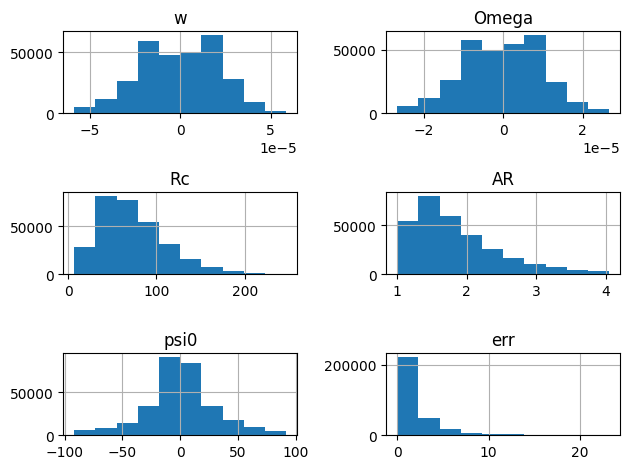

In [7]:
df = df_clean.copy()
df['err'] = err[final_mask]
df.hist(['w', 'Omega', 'Rc', 'AR', 'psi0', 'err'])
plt.tight_layout()
df.head()


Tracking

In [8]:
df_data = df_clean.copy()
df_data = df_data.rename(columns={'nCyc': 'Cyc'})
df_data['eddy_idx'] = df_data.groupby('Day').cumcount()
df_data


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR,eddy_idx
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028,1.497688,0
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171,1.491752,1
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458,1.969122,2
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705,1.207563,3
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546,1.519659,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303158,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,0.000012,110.552001,-72.997132,43.099927,1.389622,17
303159,10650,10641,973.0,126.0,CE,978.294053,127.970950,-0.000004,"[[0.6233322936879349, -0.5502050858849237], [-...",-0.000001,-0.000002,75.127332,4.241051,34.482872,2.273400,18
303160,10650,10641,805.0,95.0,AE,804.765913,95.382012,0.000011,"[[1.2619918374118362, 0.3980497594289241], [0....",0.000005,0.000006,60.426625,-10.779905,45.893895,1.523600,19
303161,10650,10641,157.0,34.0,CE,157.210669,33.449590,-0.000007,"[[0.9874338034387458, 0.628992620695803], [0.6...",-0.000003,-0.000004,141.142981,36.082072,34.764443,1.864486,20


Optimal R = 1

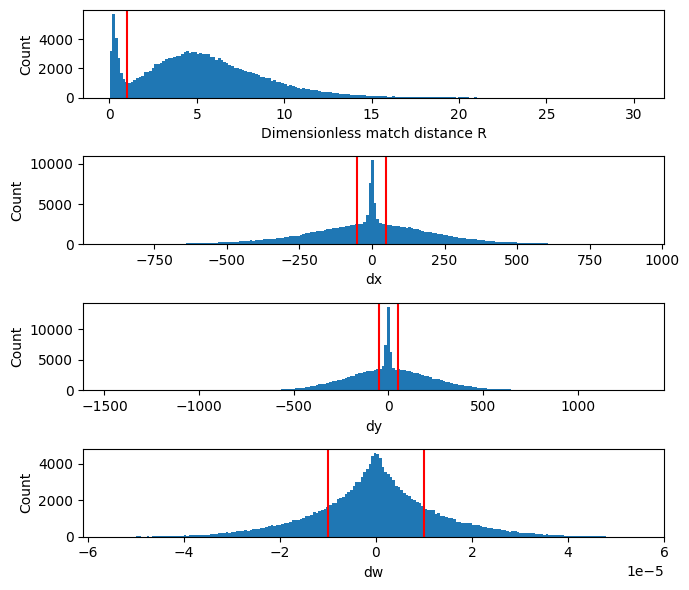

In [9]:
df = df_data.copy()
df_R = collect_tracking_R(
    df,
    L_SCALE=50,
    W_SCALE=1e-5,
    LOOKBACK=4
)

fig, axes = plt.subplots(4, 1, figsize=(7, 6), sharex=False)

# R
axes[0].hist(df_R['R'], bins=200)
axes[0].axvline(1, color='r')
axes[0].set_xlabel('Dimensionless match distance R')
axes[0].set_ylabel('Count')

# dx
axes[1].hist(df_R['dx'], bins=200)
axes[1].axvline(-50, color='r')
axes[1].axvline(50, color='r')
axes[1].set_xlabel('dx')
axes[1].set_ylabel('Count')

# dy
axes[2].hist(df_R['dy'], bins=200)
axes[2].axvline(-50, color='r')
axes[2].axvline(50, color='r')
axes[2].set_xlabel('dy')
axes[2].set_ylabel('Count')

# dw
axes[3].hist(df_R['dw'], bins=200)
axes[3].axvline(-1e-5, color='r')
axes[3].axvline(1e-5, color='r')
axes[3].set_xlabel('dw')
axes[3].set_ylabel('Count')

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Frequency')

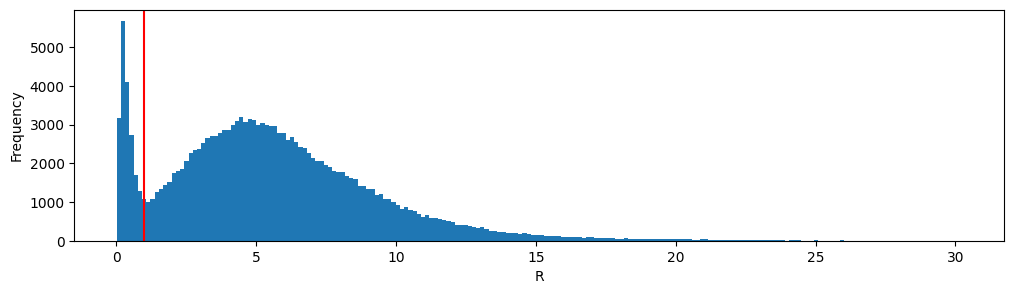

In [13]:
# R
fig, ax = plt.subplots(figsize=(12,3))
ax.hist(df_R['R'], bins=200)
ax.axvline(1, color='r')
ax.set_xlabel('R')
ax.set_ylabel('Frequency')




Tracking

In [8]:
df = df_data.copy()#[df_data.Day <= df_data.Day.min() + 200]

start_ID = np.arange(len(df[df.Day==df.Day.min()]))
next_num = np.max(start_ID) + 1

df_tracked = tracking_kdtree(
    df,
    start_ID=start_ID,
    next_num=next_num,
    L_SCALE=50,
    W_SCALE=1e-5,
    R_THRESH=1, 
    LOOKBACK=4
)


Day 1600, elapsed: 34.98s
Day 1800, elapsed: 98.31s
Day 2000, elapsed: 143.38s
Day 2200, elapsed: 196.66s
Day 2400, elapsed: 252.86s
Day 2600, elapsed: 330.59s
Day 2800, elapsed: 394.92s
Day 3000, elapsed: 455.11s
Day 3200, elapsed: 514.33s
Day 3400, elapsed: 554.69s
Day 3600, elapsed: 608.09s
Day 3800, elapsed: 656.66s
Day 4000, elapsed: 733.34s
Day 4200, elapsed: 789.90s
Day 4400, elapsed: 847.35s
Day 4600, elapsed: 892.89s
Day 4800, elapsed: 953.88s
Day 5000, elapsed: 1013.99s
Day 5200, elapsed: 1068.95s
Day 5400, elapsed: 1128.60s
Day 5600, elapsed: 1176.97s
Day 5800, elapsed: 1235.91s
Day 6000, elapsed: 1282.81s
Day 6200, elapsed: 1352.94s
Day 6400, elapsed: 1406.29s
Day 6600, elapsed: 1469.12s
Day 6800, elapsed: 1529.21s
Day 7000, elapsed: 1592.22s
Day 7200, elapsed: 1646.94s
Day 7400, elapsed: 1693.31s
Day 7600, elapsed: 1744.01s
Day 7800, elapsed: 1793.02s
Day 8000, elapsed: 1858.35s
Day 8200, elapsed: 1906.88s
Day 8400, elapsed: 1974.15s
Day 8600, elapsed: 2020.68s
Day 8800, e

In [9]:
df_tracked


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR,eddy_idx,Eddy,next_num
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028,1.497688,0,0,79010
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171,1.491752,1,1,79010
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458,1.969122,2,2,79010
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705,1.207563,3,3,79010
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546,1.519659,4,4,79010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303158,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,0.000012,110.552001,-72.997132,43.099927,1.389622,17,79008,79010
303159,10650,10641,973.0,126.0,CE,978.294053,127.970950,-0.000004,"[[0.6233322936879349, -0.5502050858849237], [-...",-0.000001,-0.000002,75.127332,4.241051,34.482872,2.273400,18,78991,79010
303160,10650,10641,805.0,95.0,AE,804.765913,95.382012,0.000011,"[[1.2619918374118362, 0.3980497594289241], [0....",0.000005,0.000006,60.426625,-10.779905,45.893895,1.523600,19,78944,79010
303161,10650,10641,157.0,34.0,CE,157.210669,33.449590,-0.000007,"[[0.9874338034387458, 0.628992620695803], [0.6...",-0.000003,-0.000004,141.142981,36.082072,34.764443,1.864486,20,78976,79010


In [10]:
path = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tracked_old.pkl'
df_tracked.to_pickle(path)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


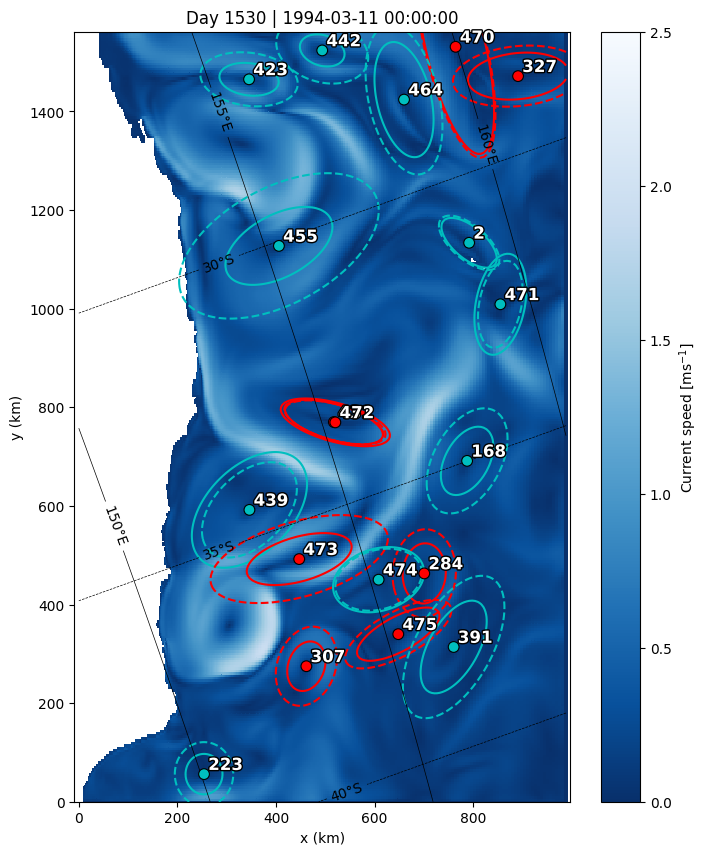

In [11]:
day_plot(1530, df_tracked)
